# Comparison of Dtype Precisions

## Import Libraries

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import time, statistics
from numba import njit

## Numba Implementation with dtype Parameter

In [2]:
@njit
def compute_numba_naive_mandelbrot(x_min, x_max, y_min, y_max, max_iterations, bound, power, res, precision):
    x_region = np.linspace(x_min, x_max, res).astype(precision)
    y_region = np.linspace(y_min, y_max, res).astype(precision)
    
    result = np.zeros((res,res), dtype=np.int32)

    for i in range(res):
        for j in range(res):
            c = x_region[j] + y_region[i] * 1j
            z = 0j
            n = 0

            while n < max_iterations and z.real*z.real + z.imag*z.imag <= bound*bound:
                z = z*z + c
                n += 1
            result[i,j] = n

    return result

## Benchmark and Inspect

Max Difference: 33


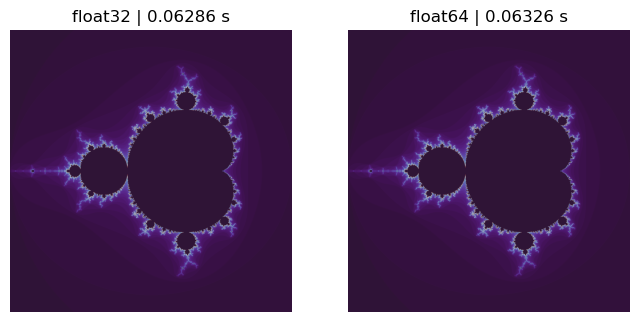

In [5]:
x_min, x_max = -2, 1
y_min, y_max = -1.5, 1.5

res = 1024
max_iterations = 100
bound = 2
power = 2

dtype_precisions = [np.float32, np.float64]
test_times = []
prec_results = []

for dtype in dtype_precisions:
    warm_up = compute_numba_naive_mandelbrot(x_min, x_max, y_min, y_max, 1, bound, power, res, dtype)
    start_time = time.perf_counter()
    prec_result = compute_numba_naive_mandelbrot(x_min, x_max, y_min, y_max, max_iterations, bound, power, res, dtype)
    test_time = time.perf_counter() - start_time
    # save data
    test_times.append(test_time)
    prec_results.append(prec_result)

fig, axes = plt.subplots(1, len(dtype_precisions), figsize=(8, 4))
for i, (ax, result, precision) in enumerate(zip(axes, prec_results, dtype_precisions)):
    ax.imshow(result, cmap='twilight_shifted')
    ax.set_title(f'{precision.__name__} | {test_times[i]:.5f} s')
    ax.axis('off')

float_diff = np.abs(prec_results[0] - prec_results[1]).max()
print(f'Max Difference: {float_diff}')

## Conclusion
In the above figure, we can see that there is barely any time save when computing at a lower precision. While the the 2 set look identical, they do have a max different in iteration count in at least 2 place (mandelbrot is symmetrical), most likely along the edges, which is kind of the most important part.

There I would just stick to using the `np.float64` precision, which is already the default.

Just to further prove my point I will run the same test with a higher `max_iteration`

Max Difference: 1085


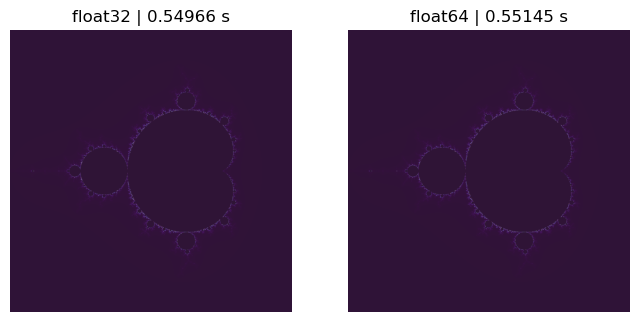

In [6]:
max_iterations = 1234
test_times = []
prec_results = []

for dtype in dtype_precisions:
    warm_up = compute_numba_naive_mandelbrot(x_min, x_max, y_min, y_max, 1, bound, power, res, dtype)
    start_time = time.perf_counter()
    prec_result = compute_numba_naive_mandelbrot(x_min, x_max, y_min, y_max, max_iterations, bound, power, res, dtype)
    test_time = time.perf_counter() - start_time
    # save data
    test_times.append(test_time)
    prec_results.append(prec_result)

fig, axes = plt.subplots(1, len(dtype_precisions), figsize=(8, 4))
for i, (ax, result, precision) in enumerate(zip(axes, prec_results, dtype_precisions)):
    ax.imshow(result, cmap='twilight_shifted')
    ax.set_title(f'{precision.__name__} | {test_times[i]:.5f} s')
    ax.axis('off')

float_diff = np.abs(prec_results[0] - prec_results[1]).max()
print(f'Max Difference: {float_diff}')

## Conclusion (continued)
Again we see the the lower precision of `np.float32` is barely faster than that of `np.float64`, while we see that the increase `max_iterations` has also increased the max difference by a lot...